# ☕ EDA — Coffee Quality Classification
### Proyecto Grupal — Clasificación de Calidad de Café

---

## 📖 ¿Qué es un EDA y para qué sirve?

El **Análisis Exploratorio de Datos (EDA)** es el primer paso de todo proyecto de Machine Learning.  
Antes de entrenar cualquier modelo, necesitamos **entender** los datos:
- ¿Qué hay en el dataset?
- ¿Los datos están limpios o tienen errores?
- ¿Qué variables son importantes?
- ¿Hay patrones o relaciones entre variables?

**Analogía:** El EDA es como leer el manual de instrucciones antes de montar un mueble. Puedes saltártelo, pero luego te sobran tornillos.

---

## 🗺️ Hoja de Ruta del Notebook

| Bloque | Qué vamos a hacer |
|--------|-------------------|
| **0** | Importar librerías y cargar datos |
| **1** | Primera inspección del dataset |
| **2** | Análisis de valores nulos |
| **3** | Crear la variable objetivo (target) |
| **4** | Análisis de variables numéricas (sensoriales) |
| **5** | Análisis de variables categóricas (origen, proceso) |
| **6** | Correlaciones entre variables |
| **7** | Detección de outliers |
| **8** | Conclusiones y próximos pasos |

---

> ⚠️ **Importante:** Ejecuta las celdas en orden, de arriba a abajo. Cada celda depende de la anterior.

---
## 📦 BLOQUE 0 — Importar librerías y cargar el dataset

**¿Qué son las librerías?**  
Son colecciones de funciones ya escritas por otros que podemos reutilizar.  
- `pandas` → manipular tablas de datos  
- `numpy` → cálculos matemáticos  
- `matplotlib` y `seaborn` → crear gráficos  
- `warnings` → ocultar avisos que no nos interesan

In [1]:
# ─── Cargar de librerías  ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import warnings

In [21]:
# ─── Cargar el dataset ────────────────────────────────────────────────────────
# 📌 ACCIÓN: Cambia la ruta al lugar donde tienes guardado el CSV
# Descarga el dataset desde: https://www.kaggle.com/datasets/fatihb/coffee-quality-data-cqi
#La ruta no modificarla. Y poner el mismo nombre todos.

df = pd.read_csv('../data/raw/coffee_quality.csv')

print(f'✅ Dataset cargado correctamente')
print(f'📊 Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')

✅ Dataset cargado correctamente
📊 Dimensiones: 207 filas x 41 columnas


---
## 🔍 BLOQUE 1 — Primera inspección del dataset

**Objetivo:** Entender qué hay dentro del dataset sin entrar en detalles todavía.  
Es como abrir una caja y ver qué hay dentro antes de sacar nada.

**Preguntas que vamos a responder:**
- ¿Cuántas filas y columnas tiene?
- ¿Qué significa cada columna?
- ¿Qué tipo de dato tiene cada columna (número, texto, fecha)?

In [22]:
# Ver las primeras 5 filas del dataset (head)
# Esto nos da una idea visual de cómo están organizados los datos
df.head(3)

,Unnamed: 0,ID,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,...,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration,Certification Body,Certification Address,Certification Contact
0,0,0,Colombia,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1700-1930,"Piendamo,Cauca",...,89.33,11.8,0,0,green,3,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
1,1,1,Taiwan,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200,Chiayi,...,87.58,10.5,0,0,blue-green,0,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
2,2,2,Laos,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300,Laos Borofen Plateau,...,87.42,10.4,0,0,yellowish,2,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"


In [23]:
# Información general del dataset
# 'object' = texto | 'float64/int64' = número
print('ℹ️ Información del dataset:')
df.info()

ℹ️ Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             207 non-null    int64  
 1   ID                     207 non-null    int64  
 2   Country of Origin      207 non-null    str    
 3   Farm Name              205 non-null    str    
 4   Lot Number             206 non-null    str    
 5   Mill                   204 non-null    str    
 6   ICO Number             75 non-null     str    
 7   Company                207 non-null    str    
 8   Altitude               206 non-null    str    
 9   Region                 205 non-null    str    
 10  Producer               206 non-null    str    
 11  Number of Bags         207 non-null    int64  
 12  Bag Weight             207 non-null    str    
 13  In-Country Partner     207 non-null    str    
 14  Harvest Year           207 non-null    st

In [24]:
# Estadísticas descriptivas de las columnas numéricas (describe)
# count=cuántos valores hay | mean=promedio | std=dispersión | min/max=extremos
df.describe()

,Unnamed: 0,ID,Number of Bags,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean Cup,Sweetness,Overall,Defects,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Category Two Defects
count,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.00000,207.000000,207.000000,207.000000,207.0,207.0,207.000000,207.0,207.000000,207.000000,207.000000,207.000000,207.000000
mean,103.000000,103.000000,155.449275,7.721063,7.744734,7.599758,7.69029,7.640918,7.644058,9.990338,10.0,10.0,7.676812,0.0,83.706570,10.735266,0.135266,0.690821,2.251208
std,59.899917,59.899917,244.484868,0.287626,0.279613,0.275911,0.25951,0.233499,0.256299,0.103306,0.0,0.0,0.306359,0.0,1.730417,1.247468,0.592070,1.686918,2.950183
min,0.000000,0.000000,1.000000,6.500000,6.750000,6.670000,6.83000,6.830000,6.670000,8.670000,10.0,10.0,6.670000,0.0,78.000000,0.000000,0.000000,0.000000,0.000000
25%,51.500000,51.500000,1.000000,7.580000,7.580000,7.420000,7.50000,7.500000,7.500000,10.000000,10.0,10.0,7.500000,0.0,82.580000,10.100000,0.000000,0.000000,0.000000
50%,103.000000,103.000000,14.000000,7.670000,7.750000,7.580000,7.67000,7.670000,7.670000,10.000000,10.0,10.0,7.670000,0.0,83.750000,10.800000,0.000000,0.000000,1.000000
75%,154.500000,154.500000,275.000000,7.920000,7.920000,7.750000,7.87500,7.750000,7.790000,10.000000,10.0,10.0,7.920000,0.0,84.830000,11.500000,0.000000,1.000000,3.000000
max,206.000000,206.000000,2240.000000,8.580000,8.500000,8.420000,8.58000,8.250000,8.420000,10.000000,10.0,10.0,8.580000,0.0,89.330000,13.500000,5.000000,12.000000,16.000000


In [25]:
# MIO
# Ver todas las columnas, las object también
df.describe(include='object')

C:\Users\user\AppData\Local\Temp\ipykernel_16940\3184131762.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,Producer,Bag Weight,...,Grading Date,Owner,Variety,Status,Processing Method,Color,Expiration,Certification Body,Certification Address,Certification Contact
count,207,205,206,204,75,207,206,205,206,207,...,207,207,201,207,202,207,207,207,207,207
unique,22,172,187,162,67,72,97,120,172,39,...,75,80,48,1,10,12,75,21,21,21
top,Taiwan,Doi Tung Development Project,1,Dry Mill,non,Taiwan Coffee Laboratory,1200,Chiayi,Doi Tung Development Project,30 kg,...,"November 15th, 2022",Taiwan Coffee Laboratory 台灣咖啡研究室,Gesha,Completed,Washed / Wet,green,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
freq,61,7,11,11,5,51,23,12,7,39,...,40,30,27,207,124,101,40,83,83,83


In [26]:
# Ver el nombre de todas las columnas disponibles
df.columns

Index(['Unnamed: 0', 'ID', 'Country of Origin', 'Farm Name', 'Lot Number',
       'Mill', 'ICO Number', 'Company', 'Altitude', 'Region', 'Producer',
       'Number of Bags', 'Bag Weight', 'In-Country Partner', 'Harvest Year',
       'Grading Date', 'Owner', 'Variety', 'Status', 'Processing Method',
       'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance',
       'Uniformity', 'Clean Cup', 'Sweetness', 'Overall', 'Defects',
       'Total Cup Points', 'Moisture Percentage', 'Category One Defects',
       'Quakers', 'Color', 'Category Two Defects', 'Expiration',
       'Certification Body', 'Certification Address', 'Certification Contact'],
      dtype='str')

---
## 🕳️ BLOQUE 2 — Análisis de valores nulos

**¿Qué es un valor nulo?**  
Un valor nulo (NaN = Not a Number) es una celda vacía en nuestros datos.  
Ocurre cuando la información no estaba disponible o no se registró.

**¿Por qué importa?**  
Los modelos de ML no pueden trabajar con valores vacíos. Tenemos que decidir qué hacer con ellos:  
- **Eliminar** la fila o columna  
- **Rellenar** con un valor (media, mediana, moda)

**Regla general:**  
- Si una columna tiene `> 40% nulos` → considerar eliminarla  
- Si tiene `< 40% nulos` → rellenar (imputar)

In [27]:
# Contar valores nulos por columna (isnull().sum())
df.isnull().sum()

Unnamed: 0                 0
ID                         0
Country of Origin          0
Farm Name                  2
Lot Number                 1
Mill                       3
ICO Number               132
Company                    0
Altitude                   1
Region                     2
Producer                   1
Number of Bags             0
Bag Weight                 0
In-Country Partner         0
Harvest Year               0
Grading Date               0
Owner                      0
Variety                    6
Status                     0
Processing Method          5
Aroma                      0
Flavor                     0
Aftertaste                 0
Acidity                    0
Body                       0
Balance                    0
Uniformity                 0
Clean Cup                  0
Sweetness                  0
Overall                    0
Defects                    0
Total Cup Points           0
Moisture Percentage        0
Category One Defects       0
Quakers       

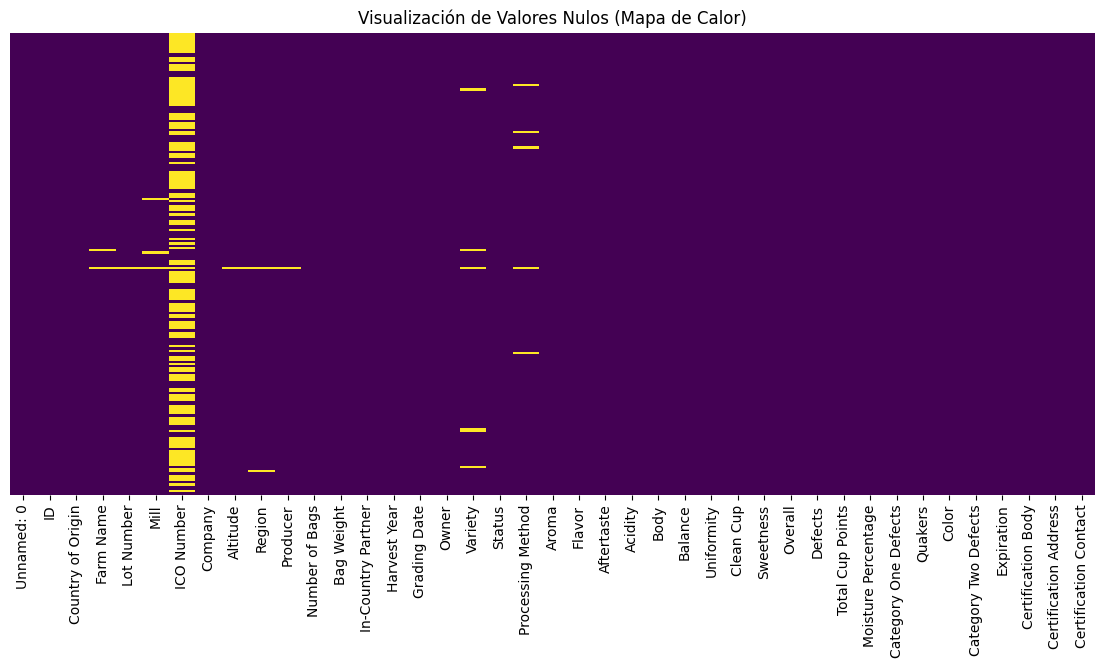

In [28]:
# Visualizar los nulos con un heatmap (Solo si lo ven necesario)

# 2. Configurar el tamaño de la figura (opcional pero recomendado)
plt.figure(figsize=(14, 6))

# 3. Crear el heatmap
# df.isnull() devuelve True donde hay nulos y False donde no
sn.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)

# 4. Mostrar el gráfico
plt.title("Visualización de Valores Nulos (Mapa de Calor)")
plt.show()

In [10]:
# MIO
df['Color'].value_counts()

Color
green            101
greenish          36
bluish-green      21
blue-green        12
yellow-green      10
brownish           9
pale yellow        6
yellow green       5
yellowish          4
yellow- green      1
browish-green      1
yello-green        1
Name: count, dtype: int64

In [11]:
# MIO
df['Country of Origin'].value_counts()

Country of Origin
Taiwan                          61
Guatemala                       21
Colombia                        19
Honduras                        13
Thailand                        12
Ethiopia                        11
Brazil                          10
Costa Rica                       8
Nicaragua                        7
El Salvador                      7
Tanzania, United Republic Of     6
United States (Hawaii)           5
Peru                             4
Vietnam                          4
Mexico                           4
Laos                             3
Uganda                           3
Indonesia                        3
Kenya                            2
Panama                           2
Madagascar                       1
Myanmar                          1
Name: count, dtype: int64

In [12]:
# MIO
df['Altitude'].value_counts()

Altitude
1200         23
1600         12
1300          7
1250          7
1400          7
             ..
1574          1
435           1
600-800       1
1300-1800     1
850-1100      1
Name: count, Length: 97, dtype: int64

In [13]:
# MIO
df['Variety'].value_counts()

Variety
Gesha                                                           27
Caturra                                                         27
Typica                                                          23
Bourbon                                                         17
Catuai                                                          12
unknown                                                         12
Catimor                                                         11
Ethiopian Heirlooms                                              9
SL34                                                             8
Mundo Novo                                                       4
Java                                                             3
SL14                                                             3
Yellow Bourbon                                                   3
SHG                                                              3
SL28                                                  

In [14]:
# MIO
df['Processing Method'].value_counts()

Processing Method
Washed / Wet                            124
Natural / Dry                            46
Pulped natural / honey                   25
Double Anaerobic Washed                   1
Semi Washed                               1
Honey,Mossto                              1
Double Carbonic Maceration / Natural      1
Wet Hulling                               1
Anaerobico 1000h                          1
SEMI-LAVADO                               1
Name: count, dtype: int64

In [15]:
# MIO
df['Moisture Percentage'].value_counts()

Moisture Percentage
11.8    13
11.6    13
11.3    13
10.0    11
10.6    11
11.0     9
11.2     9
10.5     8
10.4     7
11.5     7
10.2     6
10.3     6
10.9     6
10.1     6
10.8     5
11.9     5
9.8      5
11.4     5
11.7     5
9.7      5
9.6      5
10.7     4
9.5      4
9.1      3
9.9      3
9.2      3
11.1     3
8.4      3
12.3     2
9.4      2
12.1     2
13.3     2
12.0     2
13.1     2
9.3      1
12.4     1
12.2     1
13.5     1
0.0      1
8.9      1
13.0     1
8.1      1
8.2      1
12.5     1
9.0      1
8.5      1
Name: count, dtype: int64

In [16]:
# MIO
df['Harvest Year'].value_counts()

Harvest Year
2021 / 2022    99
2022           48
2022 / 2023    42
2021           13
2023            3
2017 / 2018     1
2018 / 2019     1
Name: count, dtype: int64

In [29]:
df.columns

Index(['Unnamed: 0', 'ID', 'Country of Origin', 'Farm Name', 'Lot Number',
       'Mill', 'ICO Number', 'Company', 'Altitude', 'Region', 'Producer',
       'Number of Bags', 'Bag Weight', 'In-Country Partner', 'Harvest Year',
       'Grading Date', 'Owner', 'Variety', 'Status', 'Processing Method',
       'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance',
       'Uniformity', 'Clean Cup', 'Sweetness', 'Overall', 'Defects',
       'Total Cup Points', 'Moisture Percentage', 'Category One Defects',
       'Quakers', 'Color', 'Category Two Defects', 'Expiration',
       'Certification Body', 'Certification Address', 'Certification Contact'],
      dtype='str')

In [31]:
# ─── DECISIÓN: Qué columnas eliminar ─────────────────────────────────────────
# Estas columnas son metadata (identificadores, nombres) que no aportan al modelo
# 📌 ACCIÓN: Revisa la lista de columnas y ajusta eliminando lo que consideres
df = df.drop(['ID', 'Farm Name', 'Lot Number', 'Mill', 'ICO Number', 'Company', 'Region', 'Producer', 'Number of Bags'], axis=1)

In [32]:
df = df.drop(['Bag Weight', 'In-Country Partner', 'Grading Date', 'Owner', 'Status', 'Quakers', 'Expiration', 'Certification Body', 'Certification Address', 'Certification Contact'], axis=1)

---
## 🎯 BLOQUE 3 — Crear la variable objetivo (TARGET)

**¿Qué es el target?**  
Es la variable que queremos predecir. En nuestro caso, si un lote de café es **Specialty** o **No Specialty**.

**¿Cómo lo creamos?**  
Usamos el estándar oficial de la **Specialty Coffee Association (SCA)**:  
- `Total Cup Points >= 82.5` → **Specialty** (calidad premium)  
- `Total Cup Points < 82.5` → **No Specialty** (calidad estándar)

**⚠️ MUY IMPORTANTE:**  
Después de crear el target, debemos **eliminar `Total.Cup.Points` del dataset**.  
Si no lo hacemos, el modelo va a hacer trampa (data leakage) porque el target viene directamente de esa columna.

In [33]:
df[df['Total Cup Points'] >= 82.5]['Total Cup Points'].count()

np.int64(163)

In [34]:
df[df['Total Cup Points'] < 82.5]['Total Cup Points'].count()

np.int64(44)

In [35]:
# Crear la columna target usando el umbral de la SCA ()
UMBRAL_SPECIALTY = 82.5

# Si "total cup point" supera el limite es Specialty sino No Specialty
df['Specialty'] = np.where(df['Total Cup Points'] >= 82.5, 'Specialty', 'No Specialty')
df.head(3)

,Unnamed: 0,Country of Origin,Altitude,Harvest Year,Variety,Processing Method,Aroma,Flavor,Aftertaste,Acidity,...,Clean Cup,Sweetness,Overall,Defects,Total Cup Points,Moisture Percentage,Category One Defects,Color,Category Two Defects,Specialty
0,0,Colombia,1700-1930,2021 / 2022,Castillo,Double Anaerobic Washed,8.58,8.50,8.42,8.58,...,10.0,10.0,8.58,0.0,89.33,11.8,0,green,3,Specialty
1,1,Taiwan,1200,2021 / 2022,Gesha,Washed / Wet,8.50,8.50,7.92,8.00,...,10.0,10.0,8.50,0.0,87.58,10.5,0,blue-green,0,Specialty
2,2,Laos,1300,2021 / 2022,Java,Semi Washed,8.33,8.42,8.08,8.17,...,10.0,10.0,8.33,0.0,87.42,10.4,0,yellowish,2,Specialty


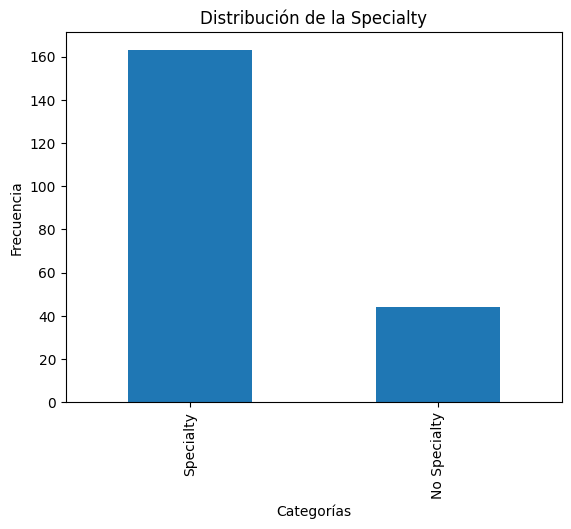

In [36]:
# Visualizar la distribución del target
# Si hay muchas más muestras de una clase que de otra = dataset DESBALANCEADO
# Un dataset desbalanceado puede engañar al modelo
# Además eliminamos Total cup Points.

# Contar valores y graficar
df['Specialty'].value_counts().plot(kind='bar')
plt.title('Distribución de la Specialty')
plt.ylabel('Frecuencia')
plt.xlabel('Categorías')
plt.show()

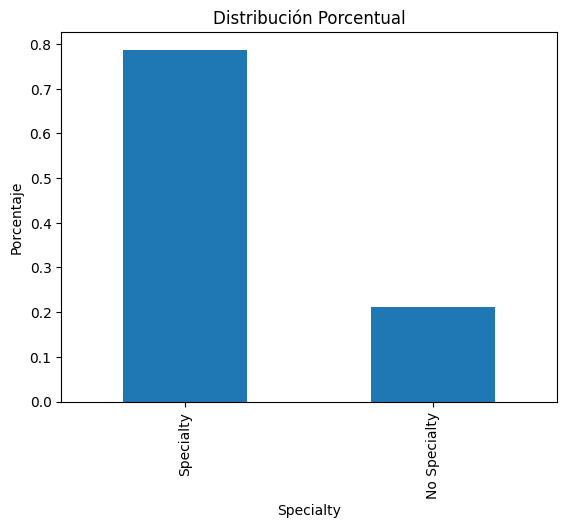

In [37]:
# MIO
df['Specialty'].value_counts(normalize=True).plot(kind='bar')
plt.title('Distribución Porcentual')
plt.ylabel('Porcentaje')
plt.show()

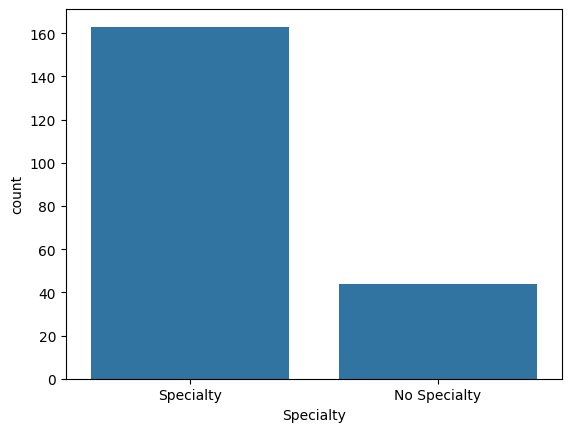

In [38]:
# MIO
sn.countplot(x='Specialty', data=df)
plt.show()

In [39]:
# MIO
# Eliminar columna Total Cup Points
df.drop('Total Cup Points', axis=1, inplace=True)
df.head(3)

,Unnamed: 0,Country of Origin,Altitude,Harvest Year,Variety,Processing Method,Aroma,Flavor,Aftertaste,Acidity,...,Uniformity,Clean Cup,Sweetness,Overall,Defects,Moisture Percentage,Category One Defects,Color,Category Two Defects,Specialty
0,0,Colombia,1700-1930,2021 / 2022,Castillo,Double Anaerobic Washed,8.58,8.50,8.42,8.58,...,10.0,10.0,10.0,8.58,0.0,11.8,0,green,3,Specialty
1,1,Taiwan,1200,2021 / 2022,Gesha,Washed / Wet,8.50,8.50,7.92,8.00,...,10.0,10.0,10.0,8.50,0.0,10.5,0,blue-green,0,Specialty
2,2,Laos,1300,2021 / 2022,Java,Semi Washed,8.33,8.42,8.08,8.17,...,10.0,10.0,10.0,8.33,0.0,10.4,0,yellowish,2,Specialty


---
## 📊 BLOQUE 4 — Análisis de variables numéricas (sensoriales)

**Objetivo:** Entender cómo se distribuyen las puntuaciones sensoriales y si hay diferencias entre cafés Specialty y No Specialty.

**¿Qué vamos a ver?**
- **Histograma:** Distribución de cada puntuación ¿es normal? ¿está sesgada?
- **Boxplot:** Comparación entre categorías de calidad
- **Violinplot:** Distribución completa por categoría

In [ ]:
# Definir las columnas sensoriales que vamos a analizar (Las variables que tenemos en Kaggel que influyen a nuestro modelo)
# Estas son las que un Q-Grader evalúa al catar un café


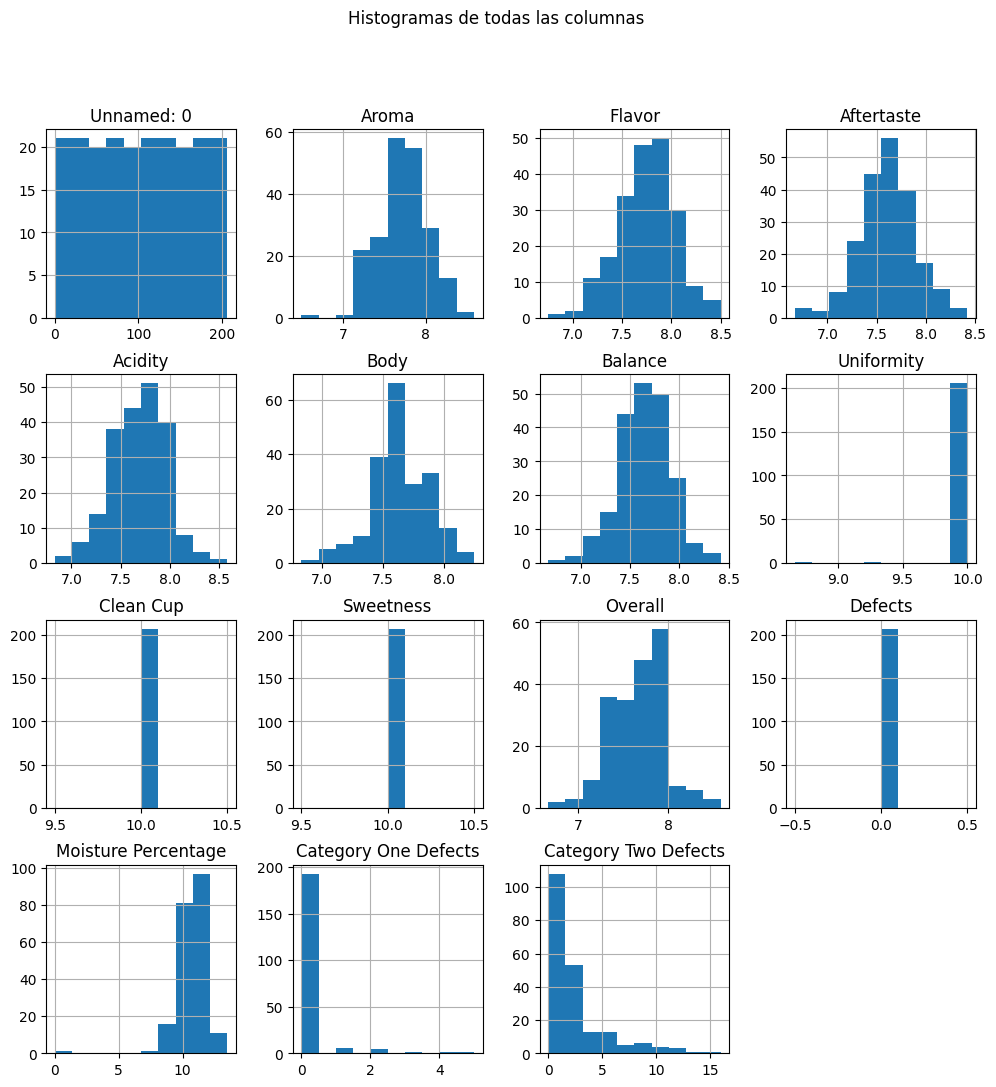

In [41]:
# ─── HISTOGRAMAS ──────────────────────────────────────────────────────────────
# Un histograma muestra cuántas muestras hay en cada rango de valores
# Ideal: distribución en forma de campana (normal)
# Si está muy sesgada hacia un lado, puede indicar outliers

# Crea un histograma para cada columna numérica del DataFrame
df.hist(bins=10, figsize=(12, 12))
plt.suptitle('Histogramas de todas las columnas')
plt.show()

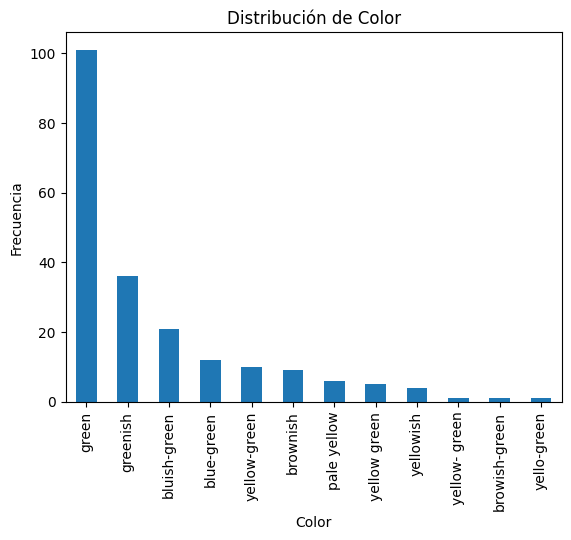

In [42]:
# Agregar las gráficas que consideren necesarias.

df['Color'].value_counts().plot(kind='bar')
plt.title('Distribución de Color')
plt.ylabel('Frecuencia')
plt.xlabel('Color')
plt.show()

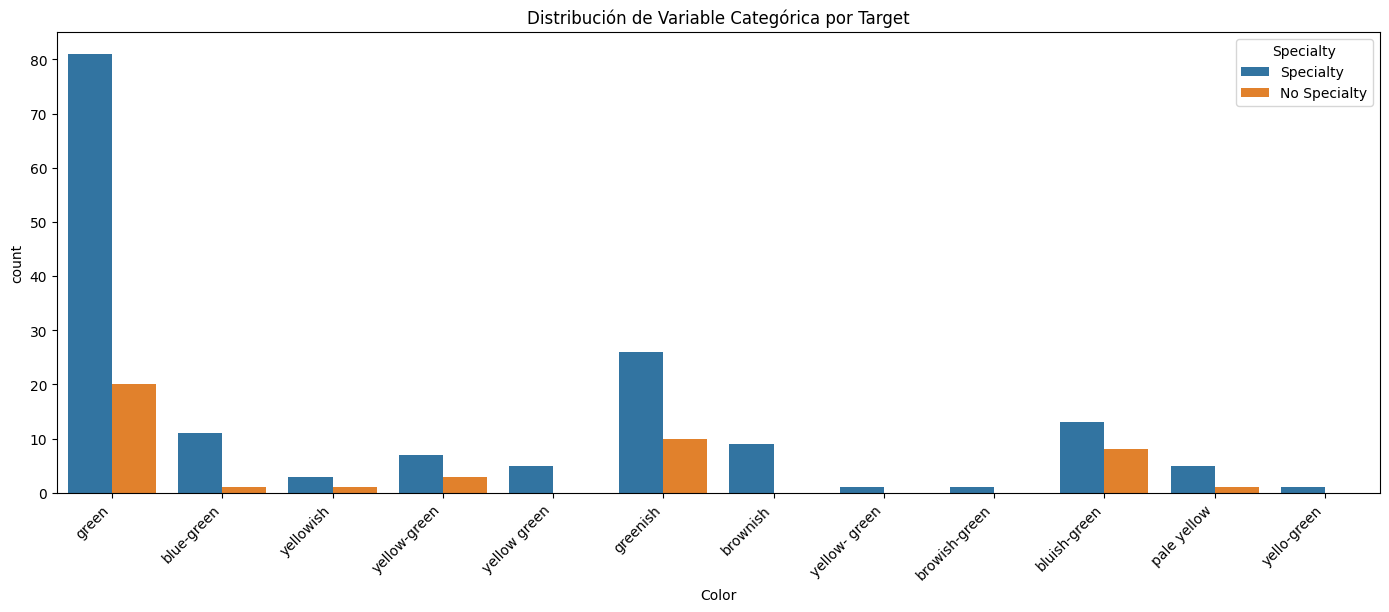

In [67]:
# MIO
# Comparar Color contra Specialty
plt.figure(figsize=(14, 6))
sn.countplot(x='Color', hue='Specialty', data=df)

# 3. Rotar los nombres en el eje X
plt.xticks(rotation=45, ha='right') # 45 grados y alineado a la derecha
plt.tight_layout()

plt.title('Distribución de Variable Categórica por Target')
plt.show()

---
## 🌍 BLOQUE 5 — Análisis de variables categóricas

**Variables categóricas:** Son las que tienen texto, como el país de origen, la variedad o el método de procesado.

**Objetivo:** Entender si el origen o el proceso del café influye en la calidad final.

EStos son solo ejemplo si ven necesarios pueden hacer sus propias preguntas y explorar.

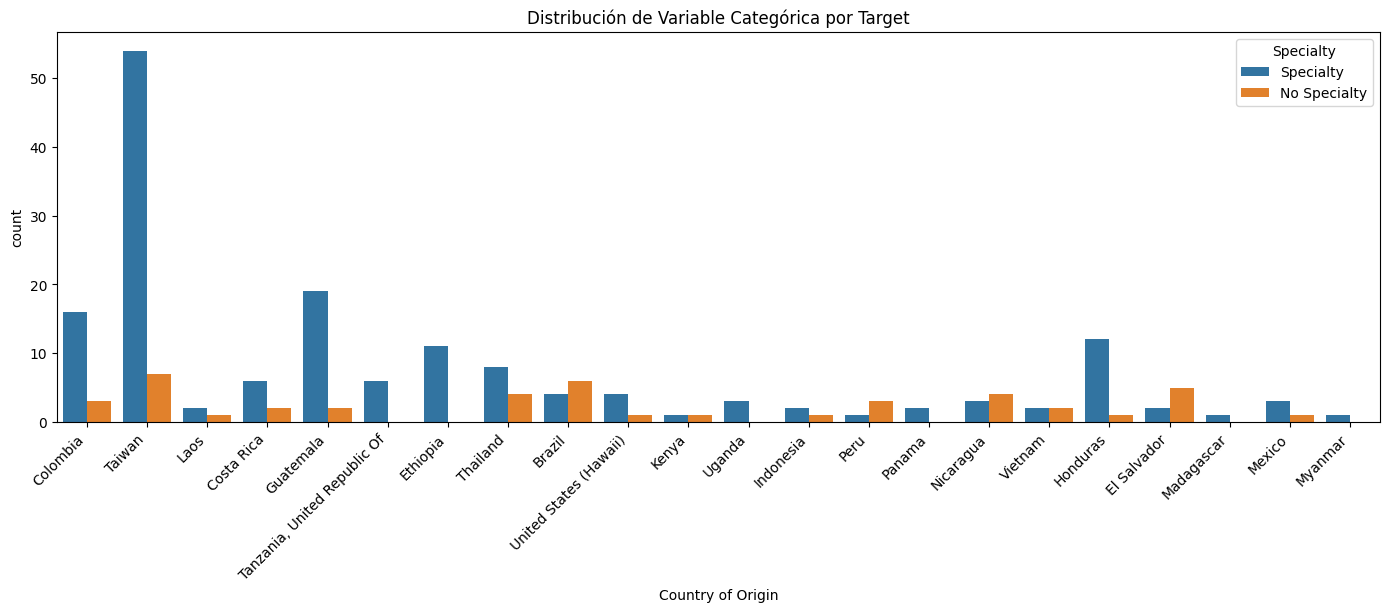

In [47]:
# ─── ANÁLISIS POR PAÍS DE ORIGEN ─────────────────────────────────────────────
# ¿Qué países producen más cafés Specialty?
plt.figure(figsize=(14, 6))
sn.countplot(x='Country of Origin', hue='Specialty', data=df)

# 3. Rotar los nombres en el eje X
plt.xticks(rotation=45, ha='right') # 45 grados y alineado a la derecha
plt.tight_layout()

plt.title('Distribución de Variable Categórica por Target')
plt.show()

In [ ]:
# ─── TASA DE SPECIALTY POR PAÍS ───────────────────────────────────────────────
# ¿Hay países donde una mayor proporción de su café es Specialty?

df['tasa_specialty'] = (df['Specialty'] == 'Specialty').astype(int)

tasa_por_pais = df.groupby('Country of Origin')['tasa_specialty'].mean()

tasa_por_pais_pct = tasa_por_pais * 100

print("Tasa (proporción) de Specialty por país:")
print(tasa_por_pais)
print("\nPorcentaje de Specialty por país:")
print(tasa_por_pais_pct)

Tasa (proporción) de Specialty por país:
Country of Origin
Brazil                          0.400000
Colombia                        0.842105
Costa Rica                      0.750000
El Salvador                     0.285714
Ethiopia                        1.000000
Guatemala                       0.904762
Honduras                        0.923077
Indonesia                       0.666667
Kenya                           0.500000
Laos                            0.666667
Madagascar                      1.000000
Mexico                          0.750000
Myanmar                         1.000000
Nicaragua                       0.428571
Panama                          1.000000
Peru                            0.250000
Taiwan                          0.885246
Tanzania, United Republic Of    1.000000
Thailand                        0.666667
Uganda                          1.000000
United States (Hawaii)          0.800000
Vietnam                         0.500000
Name: tasa_specialty, dtype: float64

P

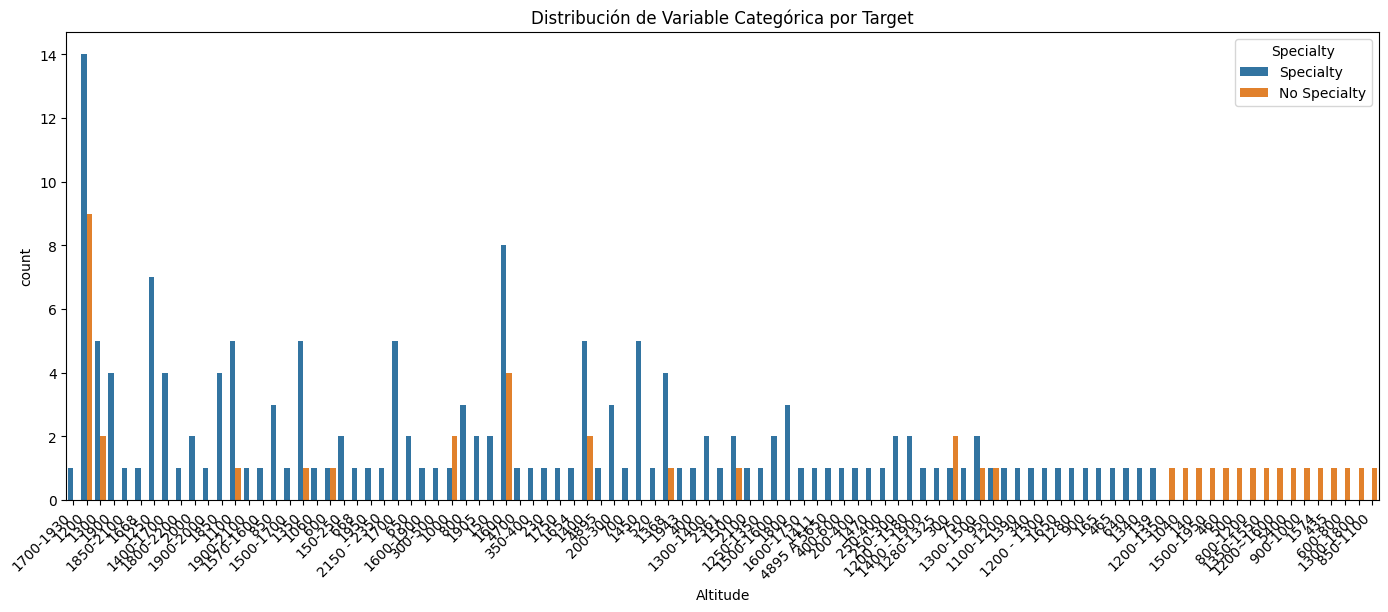

In [52]:
# MIO

# ─── ANÁLISIS POR PAÍS DE ALTITUD ─────────────────────────────────────────────
# ¿Qué altitudes producen más cafés Specialty?
plt.figure(figsize=(14, 6))
sn.countplot(x='Altitude', hue='Specialty', data=df)

# 3. Rotar los nombres en el eje X
plt.xticks(rotation=45, ha='right') # 45 grados y alineado a la derecha
plt.tight_layout()

plt.title('Distribución de Variable Categórica por Target')
plt.show()

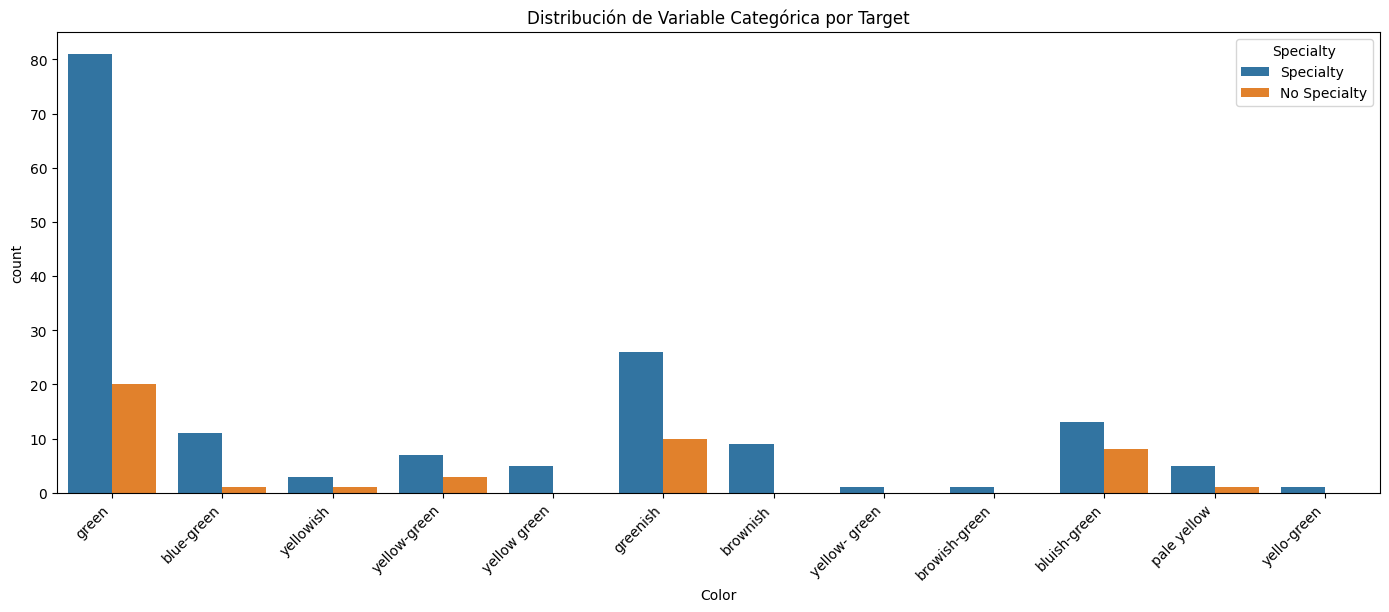

In [53]:
# MIO

# ─── ANÁLISIS POR PAÍS DE COLOR ─────────────────────────────────────────────
# ¿Qué altitudes producen más cafés Specialty?
plt.figure(figsize=(14, 6))
sn.countplot(x='Color', hue='Specialty', data=df)

# 3. Rotar los nombres en el eje X
plt.xticks(rotation=45, ha='right') # 45 grados y alineado a la derecha
plt.tight_layout()

plt.title('Distribución de Variable Categórica por Target')
plt.show()

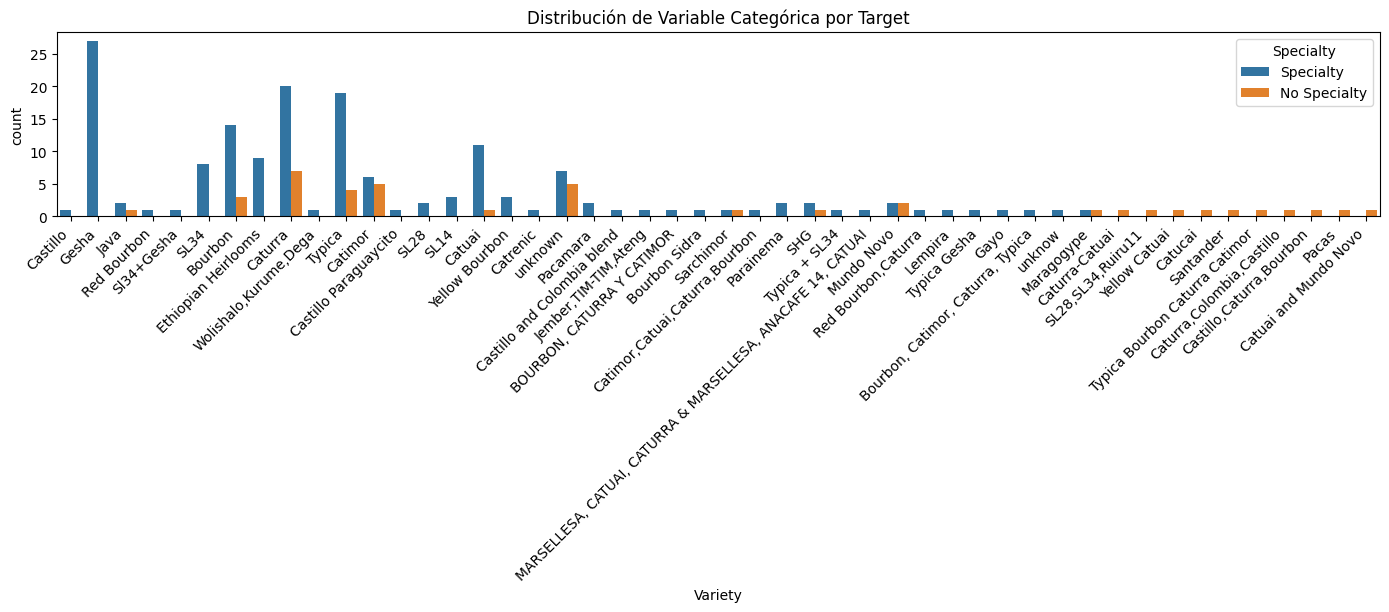

In [54]:
# MIO

# ─── ANÁLISIS POR PAÍS DE VARIEDAD ─────────────────────────────────────────────
# ¿Qué altitudes producen más cafés Specialty?
plt.figure(figsize=(14, 6))
sn.countplot(x='Variety', hue='Specialty', data=df)

# 3. Rotar los nombres en el eje X
plt.xticks(rotation=45, ha='right') # 45 grados y alineado a la derecha
plt.tight_layout()

plt.title('Distribución de Variable Categórica por Target')
plt.show()

---
## 🔥 BLOQUE 6 — Matriz de correlación

**¿Qué es la correlación?**  
Mide cuánto se relacionan dos variables numéricas entre sí.  
- Correlación `+1` → cuando una sube, la otra también sube (relación perfecta positiva)  
- Correlación `-1` → cuando una sube, la otra baja (relación perfecta negativa)  
- Correlación `0` → no hay relación

**¿Para qué sirve en ML?**
- Identificar qué variables tienen más relación con el target
- Detectar variables muy correlacionadas entre sí (redundantes) — puede ser mejor eliminar una

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            207 non-null    int64  
 1   Country of Origin     207 non-null    str    
 2   Altitude              206 non-null    str    
 3   Harvest Year          207 non-null    str    
 4   Variety               201 non-null    str    
 5   Processing Method     202 non-null    str    
 6   Aroma                 207 non-null    float64
 7   Flavor                207 non-null    float64
 8   Aftertaste            207 non-null    float64
 9   Acidity               207 non-null    float64
 10  Body                  207 non-null    float64
 11  Balance               207 non-null    float64
 12  Uniformity            207 non-null    float64
 13  Clean Cup             207 non-null    float64
 14  Sweetness             207 non-null    float64
 15  Overall               207 non-null

In [ ]:
# ─── HEATMAP DE CORRELACIÓN ───────────────────────────────────────────────────
# Solo calculamos correlación entre columnas numéricas

# Seleccionar solo las columnas numéricas
#df_correlacion = df.select_dtypes(include=['float64', 'int64'])

df_correlacion = df[['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup', 'Sweetness', 'Overall', 'Defects', 'Moisture Percentage', 'Category One Defects', 'Category Two Defects', 'Specialty']]
# Mapear valores: No Specialty=0, Specialty=1
df_correlacion['Specialty'] = df_correlacion['Specialty'].map({'No Specialty': 0, 'Specialty': 1})

matriz_corr = df_correlacion.corr()

print(matriz_corr)

                         Aroma    Flavor  Aftertaste   Acidity      Body  \
Aroma                 1.000000  0.822779    0.793397  0.712920  0.633101   
Flavor                0.822779  1.000000    0.876811  0.810934  0.739857   
Aftertaste            0.793397  0.876811    1.000000  0.814439  0.738674   
Acidity               0.712920  0.810934    0.814439  1.000000  0.765185   
Body                  0.633101  0.739857    0.738674  0.765185  1.000000   
Balance               0.745648  0.851786    0.861951  0.805236  0.816098   
Uniformity           -0.028063 -0.039767   -0.023926 -0.062564 -0.043904   
Clean Cup                  NaN       NaN         NaN       NaN       NaN   
Sweetness                  NaN       NaN         NaN       NaN       NaN   
Overall               0.801765  0.877849    0.865612  0.840583  0.771607   
Defects                    NaN       NaN         NaN       NaN       NaN   
Moisture Percentage  -0.002418 -0.050902   -0.051115 -0.016751  0.009771   
Category One

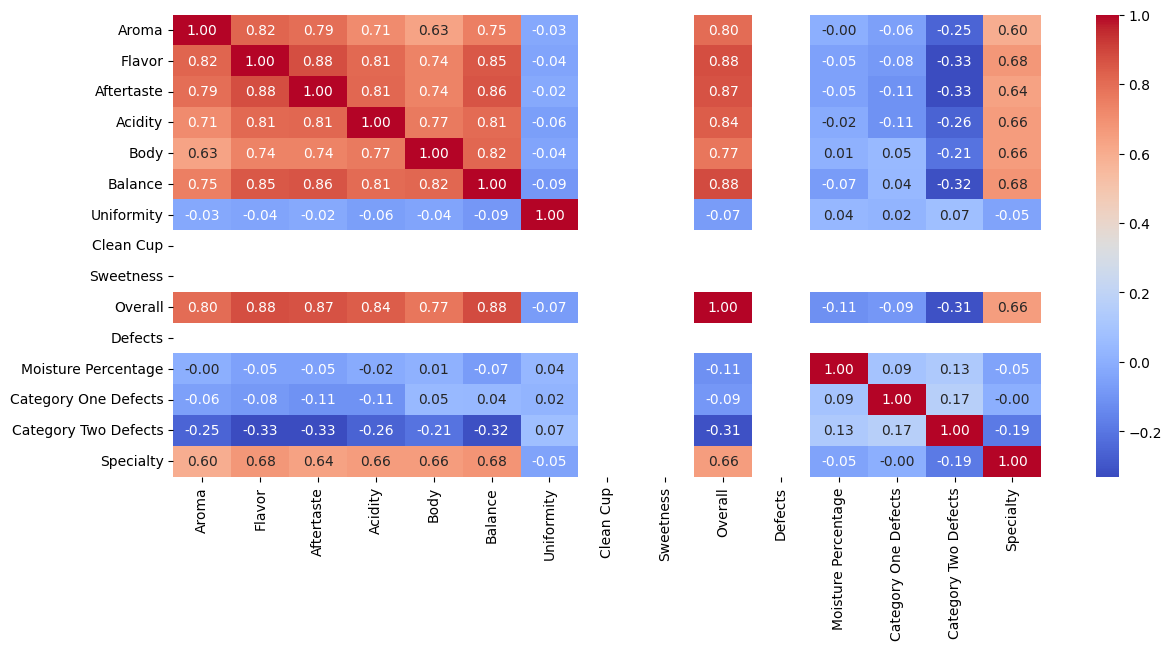

In [65]:
# 3. Pintar la matriz con Seaborn
plt.figure(figsize=(14, 6))
sn.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

---
## 🎯 BLOQUE 7 — Detección de Outliers

**¿Qué es un outlier?**  
Es un valor extremo que está muy alejado del resto.  
Por ejemplo: si todos los cafés tienen entre 7 y 9 puntos de aroma y hay uno con 1.5, ese es un outlier.

**¿Por qué importa?**  
Los outliers pueden distorsionar el modelo, haciéndolo aprender de casos excepcionales en lugar de la norma.

**Método IQR:**  
Se considera outlier cualquier valor fuera del rango `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`

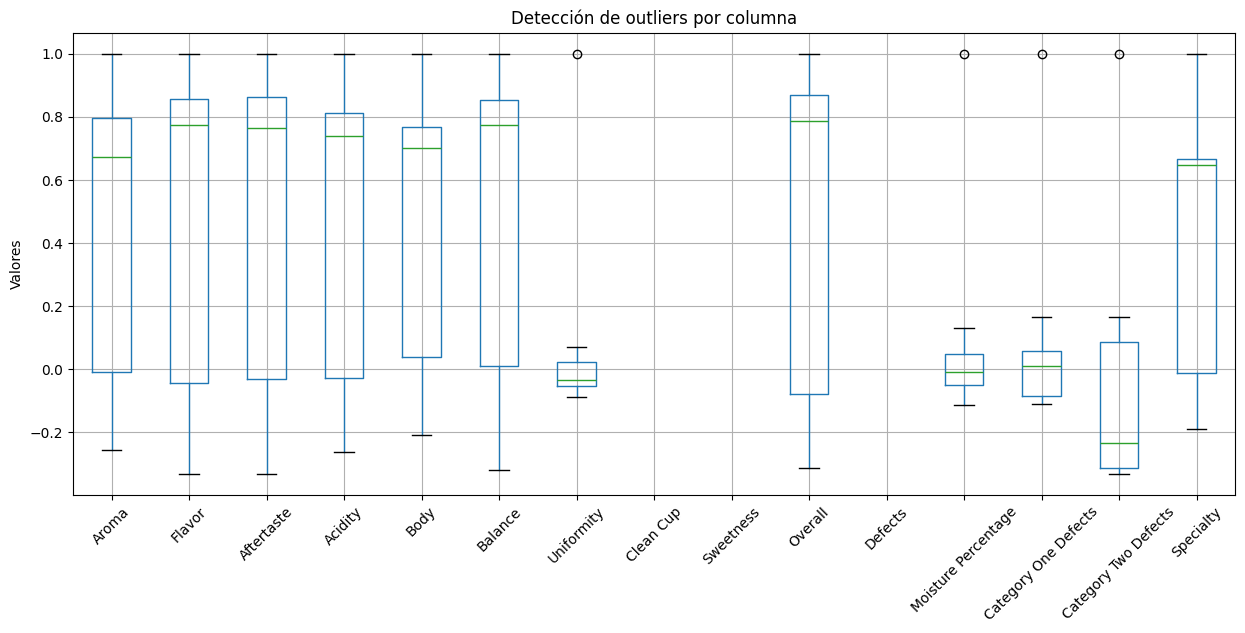

In [66]:
# ─── BOXPLOTS PARA DETECTAR OUTLIERS ─────────────────────────────────────────
# Los puntos fuera de los "bigotes" del boxplot son outliers
# Crear el boxplot
matriz_corr.boxplot(figsize=(15, 6))
plt.title('Detección de outliers por columna')
plt.ylabel('Valores')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# ─── CUANTIFICAR OUTLIERS CON EL MÉTODO IQR ───────────────────────────────────
#Para calcular si es correcto con las formulas vistas en clase (solo si ven outliers)


---
## ✅ BLOQUE 8 — Conclusiones del EDA y próximos pasos

**Completa esta sección al terminar el análisis. Aquí van vuestras conclusiones reales.**

In [ ]:
# ─── GUARDAR EL DATASET LIMPIO PARA EL SIGUIENTE NOTEBOOK ────────────────────
# Este CSV limpio será el punto de partida del notebook de preprocesamiento y modelado
# Debe esta en la carpeta processed
